# Similarity Measures: from Correlation to CKA, Distance Correlation and Taylor Diagrams

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/kernellib/blob/main/docs/notebooks/similarity_measures.ipynb)

How similar are two sets of variables? This notebook builds the answer up in steps, from Pearson's correlation to the RV coefficient, HSIC and CKA, distance correlation, MMD and energy distance. It ends with a Taylor diagram that compares several models to a reference, with kernels doing the comparison. Each measure is one kernellib call. The dependence measures are one idea, the cosine between two centred Gram matrices with a different kernel each time. MMD and energy distance are its two-sample counterpart, the distance between two mean embeddings.

**What you'll learn:**

1. The law of cosines behind correlation, RMSE and the Taylor diagram
2. The RV coefficient as the multivariate $\rho^2$, and why it is `kl.cka` with a `Linear` kernel
3. HSIC and CKA with nonlinear kernels, exact and through a Nyström approximation
4. Distance correlation and energy distance as CKA and MMD under the `Distance` kernel
5. Permutation tests for significance
6. Kernel Taylor diagrams with `kl.taylor_statistics`

## Setup

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "kernellib @ git+https://github.com/jejjohnson/kernellib@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import kernellib as kl


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,matplotlib,kernellib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.17.1

jax       : 0.11.2
matplotlib: 3.11.2
kernellib : 0.0.10

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## One variable: correlation is a cosine

Centre two samples $x, y \in \mathbb{R}^N$. Their standard deviations are norms, $\sigma_x = \|x\| / \sqrt N$, and Pearson's correlation is the cosine of the angle between them:

$$\rho(x, y) = \frac{\langle x, y \rangle}{\|x\|\,\|y\|} = \cos\theta.$$

The centred root-mean-squared difference is the third side of the triangle they span, so it follows from the law of cosines:

$$\mathrm{RMSE}'^2 = \sigma_x^2 + \sigma_y^2 - 2\,\sigma_x \sigma_y\, \rho.$$

Three numbers, one identity. Taylor (2001) turned it into a diagram: a model at radius $\sigma_y$ and angle $\arccos\rho$ sits at distance $\mathrm{RMSE}'$ from the reference. Everything below keeps this triangle and changes what the "vectors" are.

In [4]:
key = jax.random.key(0)
kx, ky, kz = jax.random.split(key, 3)
n = 500

x = jax.random.normal(kx, (n,))
y = 0.8 * x + 0.6 * jax.random.normal(ky, (n,))
xc, yc = x - x.mean(), y - y.mean()

sigma_x, sigma_y = jnp.std(x), jnp.std(y)
rho = jnp.corrcoef(x, y)[0, 1]
rmse = jnp.sqrt(jnp.mean((xc - yc) ** 2))
cosine_law = jnp.sqrt(sigma_x**2 + sigma_y**2 - 2 * sigma_x * sigma_y * rho)
print(
    f"rho = {rho:.4f}   centred RMSE = {rmse:.6f}   law of cosines = {cosine_law:.6f}"
)

rho = 0.8110   centred RMSE = 0.630032   law of cosines = 0.630032


## Many variables: the RV coefficient

With $X \in \mathbb{R}^{N \times D_x}$ and $Y \in \mathbb{R}^{N \times D_y}$ (column-centred) there is a whole cross-covariance matrix $\Sigma_{xy} = X^\top Y / N$ instead of one covariance. Its squared Frobenius (Hilbert-Schmidt) norm sums the squared covariances of every pair of features. Normalising by the self-covariances gives Escoufier's RV coefficient, the multivariate $\rho^2$:

$$\mathrm{RV}(X, Y) = \frac{\|\Sigma_{xy}\|_F^2}{\|\Sigma_{xx}\|_F\,\|\Sigma_{yy}\|_F}.$$

The same number comes out of the *sample space*. Use the $N \times N$ Gram matrices $W_x = XX^\top$ and $W_y = YY^\top$ in place of the $D \times D$ covariances. The trick $\operatorname{tr}(XX^\top YY^\top) = \|X^\top Y\|_F^2$ gives

$$\mathrm{RV}(X, Y) = \frac{\langle W_x, W_y\rangle_F}{\|W_x\|_F\,\|W_y\|_F},$$

the cosine between two Gram matrices. With centring, that is exactly centred kernel alignment (CKA) with a linear kernel. So the RV coefficient in kernellib is `kl.cka(kl.Linear(), kl.Linear(), X, Y)`.

In [5]:
kx, ky, ka = jax.random.split(jax.random.key(1), 3)
X = jax.random.normal(kx, (n, 3))
A = jax.random.normal(ka, (3, 2))
Y = X @ A + 0.8 * jax.random.normal(ky, (n, 2))

Xc, Yc = X - X.mean(0), Y - Y.mean(0)
S_xy, S_xx, S_yy = Xc.T @ Yc / n, Xc.T @ Xc / n, Yc.T @ Yc / n
rv = jnp.sum(S_xy**2) / (jnp.linalg.norm(S_xx) * jnp.linalg.norm(S_yy))
linear_cka = kl.cka(kl.Linear(), kl.Linear(), X, Y)
print(f"RV from covariances: {rv:.6f}")
print(f"linear CKA         : {linear_cka:.6f}")

RV from covariances: 0.664330
linear CKA         : 0.664330


RV sees only second-order structure. $Y$ can be a deterministic function of $X$ and still have an RV coefficient near zero, as long as the two are uncorrelated:

In [6]:
Y_sq = X**2
print(f"RV(X, X**2) = {kl.cka(kl.Linear(), kl.Linear(), X, Y_sq):.4f}")

RV(X, X**2) = 0.0066


## Nonlinear: HSIC and CKA

Replace the linear Gram matrices with those of a characteristic kernel, such as `RBF`. The centred inner product of the Gram matrices becomes the Hilbert-Schmidt Independence Criterion (Gretton et al., 2005),

$$\mathrm{HSIC}(X, Y) = \frac{1}{N^2}\operatorname{tr}(K_x H K_y H), \qquad H = I - \tfrac{1}{N}\mathbf{1}\mathbf{1}^\top,$$

the squared norm of the cross-covariance *operator* between feature spaces. In the population it is zero exactly when $X$ and $Y$ are independent, so it catches the $X^2$ relation that RV missed. CKA is the matching cosine, $\mathrm{HSIC}(X, Y) / \sqrt{\mathrm{HSIC}(X, X)\,\mathrm{HSIC}(Y, Y)}$. It lies in $[0, 1]$ and ignores the kernels' scale. Without centring, the same cosine is the (uncentred) kernel alignment `kl.kernel_alignment`, which pysim called "KA".

Set the bandwidth from the data (`kl.estimate_lengthscale`, the median heuristic). The unbiased estimator (Song et al., 2012) removes the $O(1/N)$ bias that keeps the biased one above zero for independent samples.

In [7]:
k_x = kl.RBF(lengthscale=kl.estimate_lengthscale(X))
k_y = kl.RBF(lengthscale=kl.estimate_lengthscale(Y_sq))
Z = jax.random.normal(kz, (n, 3))  # independent of X
k_z = kl.RBF(lengthscale=kl.estimate_lengthscale(Z))

print(f"{'pair':<12} {'RV':>8} {'CKA (RBF)':>10} {'HSIC_b':>10} {'HSIC_u':>10}")
for name, B, k_b in [("X, X**2", Y_sq, k_y), ("X, Z", Z, k_z)]:
    rv_ = kl.cka(kl.Linear(), kl.Linear(), X, B)
    cka_ = kl.cka(k_x, k_b, X, B)
    hb = kl.hsic(k_x, k_b, X, B)
    hu = kl.hsic(k_x, k_b, X, B, estimator="unbiased")
    print(f"{name:<12} {rv_:>8.4f} {cka_:>10.4f} {hb:>10.5f} {hu:>10.5f}")

pair               RV  CKA (RBF)     HSIC_b     HSIC_u


X, X**2        0.0066     0.2154    0.00639    0.00591
X, Z           0.0043     0.0092    0.00026   -0.00008


For large $N$, pass an unfitted feature map as `approx`. Each Gram matrix is then replaced by $\Phi\Phi^\top$ with $R$ features, and the statistic costs $O(N R^2)$ without ever forming an $N \times N$ matrix. Nyström with a few hundred landmarks is close to the exact value:

In [8]:
n_big = 4000
kb1, kb2, kb3 = jax.random.split(jax.random.key(2), 3)
X_big = jax.random.normal(kb1, (n_big, 3))
Y_big = jnp.sin(2 * X_big[:, :2]) + 0.3 * jax.random.normal(kb2, (n_big, 2))
# A quarter of the median distance: a wiggly kernel, so the rank matters.
ls_x = kl.estimate_lengthscale(X_big[:1000], scale=0.25)
ls_y = kl.estimate_lengthscale(Y_big[:1000], scale=0.25)
kx_big, ky_big = kl.RBF(lengthscale=ls_x), kl.RBF(lengthscale=ls_y)

exact = kl.cka(kx_big, ky_big, X_big, Y_big)
print(f"exact CKA (N={n_big}): {exact:.4f}")
for m in (25, 100, 400, 1600):
    approx = kl.NystromFeatures(m, kb3)
    est = kl.cka(kx_big, ky_big, X_big, Y_big, approx=approx)
    print(f"Nystrom, {m:>4} landmarks: {est:.4f}   |error| = {abs(est - exact):.1e}")

exact CKA (N=4000): 0.1984


Nystrom,   25 landmarks: 0.1456   |error| = 5.3e-02


Nystrom,  100 landmarks: 0.1947   |error| = 3.8e-03


Nystrom,  400 landmarks: 0.1979   |error| = 5.1e-04


Nystrom, 1600 landmarks: 0.1984   |error| = 6.1e-05


## Distance correlation is CKA with a distance kernel

Székely et al. (2007) built distance covariance from double-centred matrices of pairwise distances $\|x_i - x_j\|$. Its normalised version, distance correlation, is zero only under independence. Sejdinovic et al. (2013) showed it is not a separate idea. Under the *distance-induced kernel*

$$k(x, x') = \tfrac12\bigl(\|x\|^a + \|x'\|^a - \|x - x'\|^a\bigr), \qquad 0 < a \le 2,$$

the centred Gram matrix is minus half the double-centred distance matrix. That makes $\mathrm{dCov}^2 = 4\,\mathrm{HSIC}$ and $\mathrm{dCor}^2 = \mathrm{CKA}$. kernellib ships that kernel as `kl.Distance(exponent=a)`, with `kl.distance_covariance_squared` and `kl.distance_correlation_squared` as named shortcuts. At $a = 2$ the kernel is linear and dCor² falls back to RV.

Here are the four cosines side by side on classic one-dimensional relationships. Pearson's $\rho^2$ (= RV in 1-D) is built for the linear one. CKA with an RBF kernel and dCor² respond to all of them.

relation       rho^2      RV     CKA  dCor^2


linear         0.848   0.848   0.792   0.827


quadratic      0.006   0.006   0.349   0.250


sinusoid       0.114   0.114   0.084   0.158


circle         0.000   0.000   0.068   0.038


independent    0.000   0.000   0.002   0.003


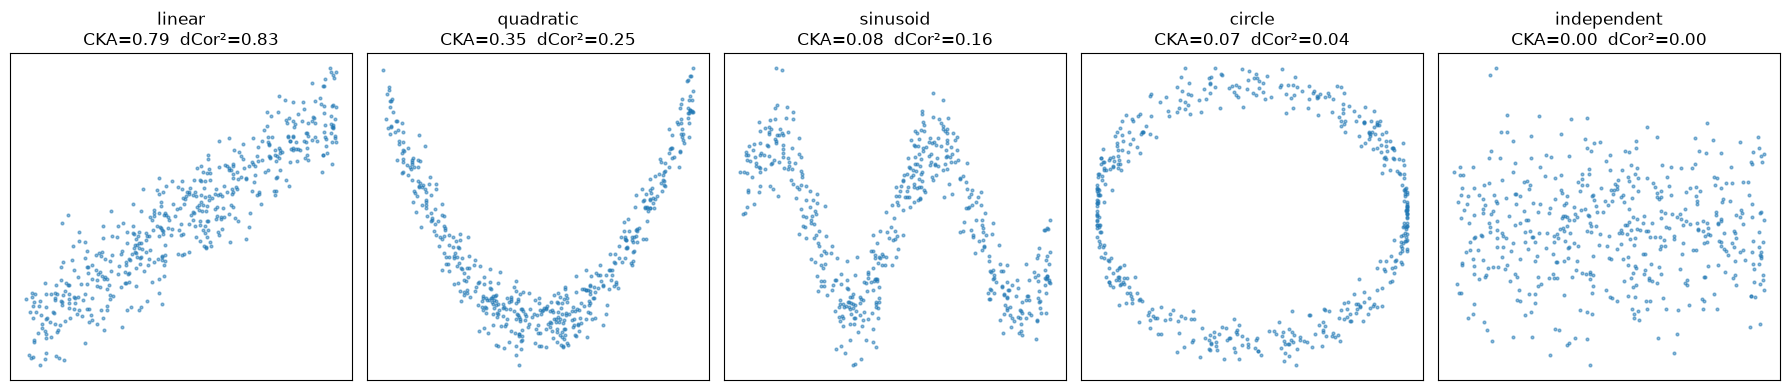

In [9]:
k1, k2, k3 = jax.random.split(jax.random.key(3), 3)
t = jax.random.uniform(k1, (n,), minval=-2.0, maxval=2.0)
eps = jax.random.normal(k2, (n,))
angle = jax.random.uniform(k3, (n,), minval=0.0, maxval=2 * jnp.pi)
relations = {
    "linear": (t, t + 0.5 * eps),
    "quadratic": (t, t**2 + 0.3 * eps),
    "sinusoid": (t, jnp.sin(3 * t) + 0.3 * eps),
    "circle": (jnp.cos(angle), jnp.sin(angle) + 0.1 * eps),
    "independent": (t, eps),
}


def four_measures(a, b):
    A, B = a[:, None], b[:, None]
    rbf_a = kl.RBF(lengthscale=kl.estimate_lengthscale(A))
    rbf_b = kl.RBF(lengthscale=kl.estimate_lengthscale(B))
    return {
        "rho^2": jnp.corrcoef(a, b)[0, 1] ** 2,
        "RV": kl.cka(kl.Linear(), kl.Linear(), A, B),
        "CKA": kl.cka(rbf_a, rbf_b, A, B),
        "dCor^2": kl.distance_correlation_squared(A, B),
    }


fig, axes = plt.subplots(1, 5, figsize=(18, 4))
print(f"{'relation':<12} {'rho^2':>7} {'RV':>7} {'CKA':>7} {'dCor^2':>7}")
for ax, (name, (a, b)) in zip(axes, relations.items(), strict=True):
    m = four_measures(a, b)
    row = " ".join(f"{float(v):>7.3f}" for v in m.values())
    print(f"{name:<12} {row}")
    ax.scatter(a, b, s=4, alpha=0.5)
    ax.set_title(f"{name}\nCKA={float(m['CKA']):.2f}  dCor²={float(m['dCor^2']):.2f}")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

Pearson's $\rho^2$ is blind to the quadratic and the circle. CKA and dCor² put every relationship well above the independent baseline and rank them in the same order. The *values* are not comparable across kinds of relationship, though: a small dCor² can still be highly significant (see below). The two measures also differ in calibration. dCor² needs no bandwidth, while CKA can be tuned to the scale of the structure. The median heuristic is too wide for the sinusoid's wiggles, and a narrower RBF kernel sees them much better:

In [10]:
a, b = relations["sinusoid"]
A, B = a[:, None], b[:, None]
for scale in (1.0, 0.5, 0.25, 0.1):
    k_a = kl.RBF(lengthscale=kl.estimate_lengthscale(A, scale=scale))
    k_b = kl.RBF(lengthscale=kl.estimate_lengthscale(B, scale=scale))
    cka_ = kl.cka(k_a, k_b, A, B)
    print(f"sinusoid, lengthscale = {scale:>4} x median: CKA = {cka_:.3f}")

sinusoid, lengthscale =  1.0 x median: CKA = 0.084
sinusoid, lengthscale =  0.5 x median: CKA = 0.224


sinusoid, lengthscale = 0.25 x median: CKA = 0.265
sinusoid, lengthscale =  0.1 x median: CKA = 0.181


## Comparing distributions: MMD and energy distance

The same geometry compares *distributions* instead of paired samples. The maximum mean discrepancy is the distance between mean embeddings in the kernel's feature space,

$$\mathrm{MMD}^2(P, Q) = \mathbb{E}\,k(x, x') + \mathbb{E}\,k(y, y') - 2\,\mathbb{E}\,k(x, y),$$

and it is zero only when $P = Q$ for a characteristic kernel. Under the distance kernel it is half of Székely & Rizzo's energy distance, $2\,\mathbb{E}\|X - Y\| - \mathbb{E}\|X - X'\| - \mathbb{E}\|Y - Y'\|$. That makes `kl.energy_distance` just `2 * kl.mmd_squared(kl.Distance(), X, Y)`. Both grow as one sample drifts away from the other:

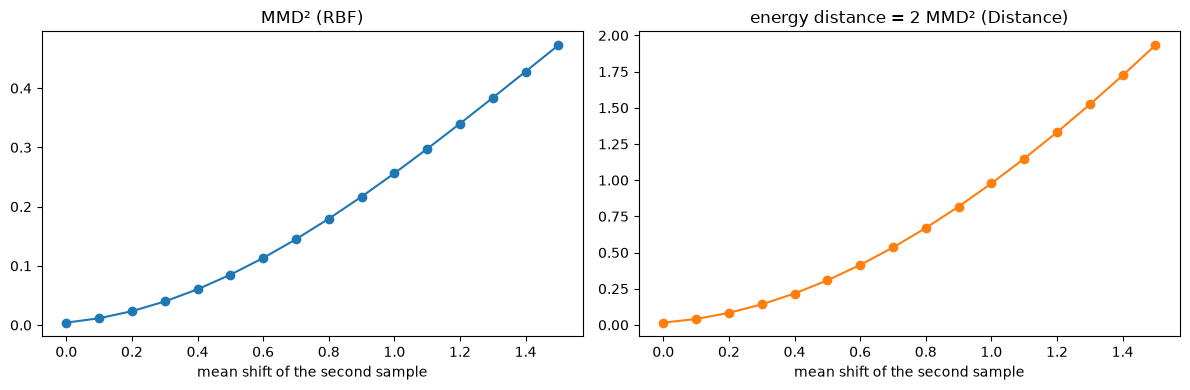

In [11]:
kp, kq = jax.random.split(jax.random.key(4))
P = jax.random.normal(kp, (300, 2))
shifts = jnp.linspace(0.0, 1.5, 16)
rbf = kl.RBF(lengthscale=kl.estimate_lengthscale(P))
mmd = [kl.mmd_squared(rbf, P, jax.random.normal(kq, (300, 2)) + s) for s in shifts]
energy = [kl.energy_distance(P, jax.random.normal(kq, (300, 2)) + s) for s in shifts]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(shifts, mmd, "o-", color="C0")
axes[0].set_title("MMD² (RBF)")
axes[1].plot(shifts, energy, "o-", color="C1")
axes[1].set_title("energy distance = 2 MMD² (Distance)")
for ax in axes:
    ax.set_xlabel("mean shift of the second sample")
plt.tight_layout()
plt.show()

## Is it significant?

A value near zero is not yet a verdict. `kl.permutation_test` shuffles the pairing (independence) or the sample labels (two-sample) to build the null distribution of any statistic. Here it tests dCor² on a small sample:

In [12]:
k_small = jax.random.key(5)
t_small, e_small = t[:60, None], eps[:60, None]
for name, B in [("quadratic", t_small**2 + 0.3 * e_small), ("independent", e_small)]:
    result = kl.permutation_test(
        kl.distance_correlation_squared, t_small, B, key=k_small, n_permutations=500
    )
    print(f"{name:<12} dCor^2 = {result.statistic:.3f}   p = {result.p_value:.3f}")

quadratic    dCor^2 = 0.265   p = 0.002


independent  dCor^2 = 0.034   p = 0.741


## Taylor diagrams with kernels

Back to the triangle. Centred Gram matrices are vectors in $\mathbb{R}^{N \times N}$ with inner product HSIC. So the law of cosines holds for them too, with HSIC norms as the radii, CKA as the cosine and the distance between centred Gram matrices as the third side:

$$\|\tilde K_x - \tilde K_y\|^2 = \|\tilde K_x\|^2 + \|\tilde K_y\|^2 - 2\,\|\tilde K_x\|\,\|\tilde K_y\|\,\mathrm{CKA}(x, y).$$

`kl.taylor_statistics` returns these four numbers from one set of HSIC values, so the triangle closes exactly. With a `Linear` kernel it is the RV diagram, which for 1-D data is the classic diagram on a squared scale. With an `RBF` kernel it also credits nonlinear agreement.

The reference is a two-variable field on a 1-D grid, and five "models" imitate it in different ways. Every model is compared with the same kernel, whose bandwidth is fitted to the reference, so the radii are comparable.

In [13]:
grid = jnp.linspace(0.0, 2 * jnp.pi, 400)
reference = jnp.stack([jnp.sin(grid), jnp.cos(2 * grid)], axis=1)
km1, km2 = jax.random.split(jax.random.key(6))
models = {
    "noisy": reference + 0.4 * jax.random.normal(km1, reference.shape),
    "amplified": 1.4 * reference,
    "phase-shifted": jnp.stack([jnp.sin(grid + 0.6), jnp.cos(2 * grid + 0.6)], 1),
    "saturated": jnp.tanh(3 * reference),
    "unrelated": 0.7 * jax.random.normal(km2, reference.shape),
}
kernels = {
    "Linear (RV diagram)": kl.Linear(),
    "RBF (kernel diagram)": kl.RBF(lengthscale=kl.estimate_lengthscale(reference)),
}

stats = {
    kname: {m: kl.taylor_statistics(k, k, reference, Y) for m, Y in models.items()}
    for kname, k in kernels.items()
}
for kname, rows in stats.items():
    print(kname)
    print(f"  {'model':<14} {'radius':>8} {'corr':>7} {'dist':>7} {'cos-law err':>12}")
    for m, s in rows.items():
        law = s.norm_x**2 + s.norm_y**2 - 2 * s.norm_x * s.norm_y * s.correlation
        err = abs(float(s.distance**2 - law))
        row = f"{s.norm_y:>8.4f} {s.correlation:>7.3f} {s.distance:>7.4f} {err:>12.1e}"
        print(f"  {m:<14} {row}")

Linear (RV diagram)
  model            radius    corr    dist  cos-law err
  noisy            0.8881   0.759  0.5788      2.8e-16
  amplified        1.3859   1.000  0.6788      0.0e+00
  phase-shifted    0.7071   0.681  0.5646      2.8e-16
  saturated        1.0946   0.941  0.4916      3.6e-16
  unrelated        0.6882   0.010  0.9819      2.2e-16
RBF (kernel diagram)
  model            radius    corr    dist  cos-law err
  noisy            0.2239   0.793  0.1472      1.4e-17
  amplified        0.3104   0.994  0.0832      1.2e-17
  phase-shifted    0.2271   0.681  0.1840      0.0e+00
  saturated        0.2925   0.957  0.0967      3.1e-17
  unrelated        0.1762   0.011  0.2906      0.0e+00


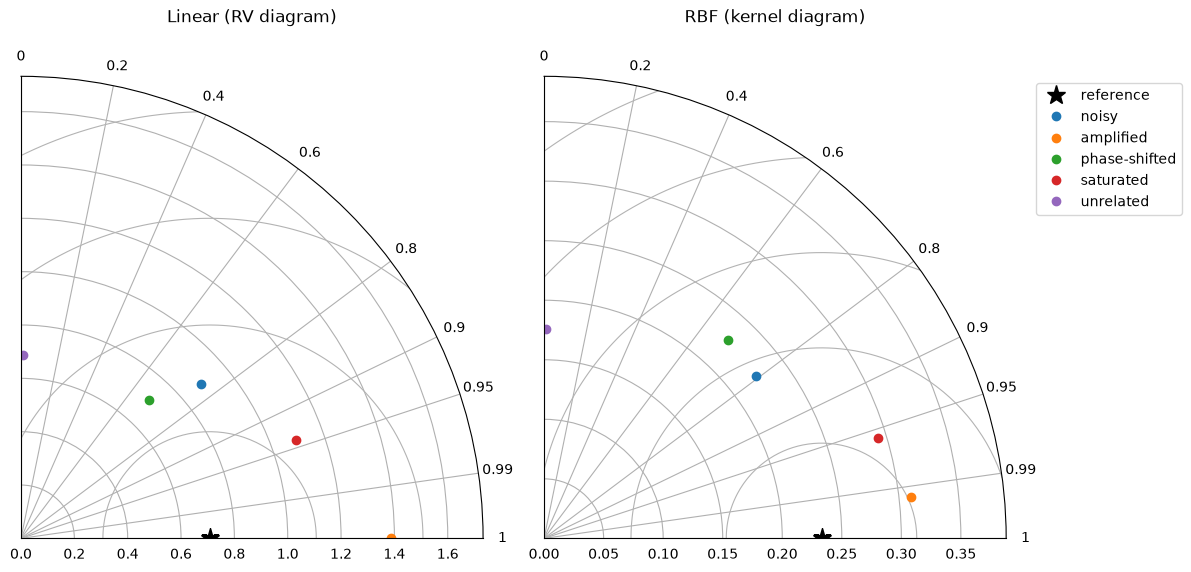

In [14]:
def taylor_axes(fig, position, r_max):
    ax = fig.add_subplot(position, projection="polar")
    ax.set_thetamin(0)
    ax.set_thetamax(90)
    ticks = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
    ax.set_thetagrids(np.degrees(np.arccos(ticks)), [f"{c:g}" for c in ticks])
    ax.set_rlim(0, r_max)
    return ax


fig = plt.figure(figsize=(12, 6))
for position, (kname, rows) in zip((121, 122), stats.items(), strict=True):
    ref = float(next(iter(rows.values())).norm_x)
    r_max = 1.25 * max(ref, *(float(s.norm_y) for s in rows.values()))
    ax = taylor_axes(fig, position, r_max)
    # Contours of the distance to the reference point: the third side.
    th, r = np.meshgrid(np.linspace(0, np.pi / 2, 90), np.linspace(0, r_max, 90))
    dist = np.sqrt(ref**2 + r**2 - 2 * ref * r * np.cos(th))
    ax.contour(th, r, dist, levels=5, colors="0.7", linewidths=0.8)
    ax.plot([0.0], [ref], "k*", markersize=14, label="reference")
    for i, (m, s) in enumerate(rows.items()):
        theta = float(jnp.arccos(jnp.clip(s.correlation, -1.0, 1.0)))
        ax.plot([theta], [float(s.norm_y)], "o", color=f"C{i}", label=m)
    ax.set_title(kname, pad=20)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0))
plt.tight_layout()
plt.show()

The two diagrams agree on the direction of each model and disagree on its distance.

- **Amplified** has exactly the reference's shape, so its RV correlation is 1. The linear radius grows with the amplitude squared, though, so the RV diagram puts it far out along the axis, farther from the reference than the noisy model. An RBF kernel of fixed bandwidth is bounded and not scale-invariant. Its correlation drops a little (0.994), but its radius barely grows, so it is the *closest* model in the kernel diagram.
- **Saturated** (`tanh`) keeps where the field is high or low but flattens its peaks. Both diagrams rate it highly; the kernel one slightly more.
- **Noisy** and **phase-shifted** lose correlation in both diagrams.
- **Unrelated** lands at 90° in both, as it should.

The grey arcs are equal distance to the reference, the "centred RMSE" of each diagram. Which diagram is right depends on the question. The RV diagram asks whether the model reproduces the reference's variance. The kernel diagram asks whether it reproduces its structure at the kernel's scale.

## Summary

**Dependence between paired samples** is the cosine, or the distance, between centred Gram matrices. Only the kernel changes:

| Measure | kernellib | Sees |
|---|---|---|
| Pearson $\rho^2$, RV coefficient | `kl.cka(kl.Linear(), kl.Linear(), X, Y)` | linear (second-order) dependence |
| HSIC / CKA | `kl.hsic(kx, ky, X, Y)`, `kl.cka(...)` | any dependence, at the kernel's scale |
| Distance covariance / correlation | `kl.distance_covariance_squared`, `kl.distance_correlation_squared` | any dependence, no bandwidth |
| Taylor diagram | `kl.taylor_statistics(kx, ky, X_ref, Y)` | radius, correlation and distance at once |

**Differences between two samples** use the uncentred Gram blocks within and across the samples, as the distance between mean embeddings:

| Measure | kernellib | Sees |
|---|---|---|
| MMD | `kl.mmd_squared(k, X, Y)` | any difference between distributions (characteristic `k`) |
| Energy distance | `kl.energy_distance(X, Y)` = `2 * kl.mmd_squared(kl.Distance(), X, Y)` | any difference, no bandwidth |

**Significance** is a separate step. `kl.permutation_test(statistic, X, Y, key=key)` turns any of these statistics into a p-value by permuting the pairing or the sample labels.

All the statistics take `jax.grad`, and all except the linear-time MMD take `estimator="biased"` or `"unbiased"`. For large $N$, `approx=` replaces each Gram matrix with a feature map. Nyström works with any kernel. Random Fourier and FastFood features need a stationary kernel with a spectral density (`RBF`, `Matern`, `RationalQuadratic`), so RV (`Linear`) and the distance statistics (`Distance`) use Nyström. The linear-time MMD estimator takes no `approx`.